# **Import**

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import shap

from tqdm import tqdm

# **All Tests in B**

In [3]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [4]:
train_b = pd.read_csv('./train_b.csv')
train_b.head()

,Test_id,Test_x,Label,Test_y,PrimaryKey,Age,TestDate,B1-1,B1-2,B1-3,...,B9-2,B9-3,B9-4,B9-5,B10-1,B10-2,B10-3,B10-4,B10-5,B10-6
0,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,B,0,B,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,60b,201912,"1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","2,4,4,2,4,4,2,2,4,2,2,4,2,4,4,2",...,0,1,34,0,20,0,2,58,0,20
1,0x689BA0A725996D44C81AF62BA981E35E1CAC54E2D85A...,B,0,B,0x689BA0A725996D44C81AF62BA981E35E1CAC54E2D85A...,60b,202002,"1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1","0,0,0.7208771,0,0.6820285,0,0.6655249,0,0.6622...","4,4,1,4,1,4,1,4,1,1,4,1,4,4,1,1",...,0,0,35,0,20,0,1,59,3,20
2,0x52908018D663ECD95A5B3F53822F28DA755E7F4A3453...,B,0,B,0x52908018D663ECD95A5B3F53822F28DA755E7F4A3453...,60b,202205,"1,1,1,2,1,1,2,1,2,1,1,1,1,1,1,1","0.6172074,0,0,0.5502462,0,0,0.6004377,1.117857...","1,4,4,1,4,4,1,1,4,1,1,4,1,4,4,1",...,0,1,34,1,20,0,1,59,2,18
3,0x8301C9E89A886F3461F2513473B6DFA6CCF3D2A90FF9...,B,0,B,0x8301C9E89A886F3461F2513473B6DFA6CCF3D2A90FF9...,70b,202210,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0.947294,0,0.7391879,0,0.5613896,0,0.52969...","4,4,1,4,1,4,1,4,1,2,4,1,4,4,1,1",...,0,0,35,0,18,2,0,60,5,19
4,0x800A6AE66459B67FB0A249B0CF8EA39E19B014A920BF...,B,0,B,0x800A6AE66459B67FB0A249B0CF8EA39E19B014A920BF...,70a,202103,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","2,4,4,4,2,4,2,4,2,2,4,4,2,2,2,4",...,0,2,33,0,20,0,0,60,0,19


In [5]:
train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297526 entries, 0 to 297525
Data columns (total 33 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     297526 non-null  object
 1   Test_x      297526 non-null  object
 2   Label       297526 non-null  int64 
 3   Test_y      297526 non-null  object
 4   PrimaryKey  297526 non-null  object
 5   Age         297526 non-null  object
 6   TestDate    297526 non-null  int64 
 7   B1-1        297517 non-null  object
 8   B1-2        297517 non-null  object
 9   B1-3        297517 non-null  object
 10  B2-1        297523 non-null  object
 11  B2-2        297523 non-null  object
 12  B2-3        297523 non-null  object
 13  B3-1        297523 non-null  object
 14  B3-2        297523 non-null  object
 15  B4-1        297523 non-null  object
 16  B4-2        297523 non-null  object
 17  B5-1        297523 non-null  object
 18  B5-2        297523 non-null  object
 19  B6          297523 non-

In [6]:
train_b = train_b.dropna()

## **Features**

In [7]:
list_cols = [
    'B1-1','B1-2','B1-3',
    'B2-1','B2-2','B2-3',
    'B3-1','B3-2',
    'B4-1','B4-2',
    'B5-1','B5-2',
    'B6','B7','B8'
]

for col in list_cols:
    train_b[col + '_list'] = train_b[col].apply(lambda x: list(map(float, x.split(','))) if isinstance(x, str) else x)

In [8]:
train_b['B1-1_ratio'] = train_b['B1-1_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B1-2_mean'] = train_b['B1-2_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_b['B1-2_var']  = train_b['B1-2_list'].apply(lambda x: np.var(x) if isinstance(x, list) else np.nan)
train_b['B1-2_std']  = train_b['B1-2_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)
train_b['B1-3_ratio'] = train_b['B1-3_list'].apply(lambda x: (x.count(1)+x.count(3))/len(x) if isinstance(x, list) else np.nan)

In [9]:
train_b['B2-1_ratio'] = train_b['B2-1_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B2-2_mean'] = train_b['B2-2_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_b['B2-2_var']  = train_b['B2-2_list'].apply(lambda x: np.var(x) if isinstance(x, list) else np.nan)
train_b['B2-2_std']  = train_b['B2-2_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)
train_b['B2-3_ratio'] = train_b['B2-3_list'].apply(lambda x: (x.count(1)+x.count(3))/len(x) if isinstance(x, list) else np.nan)

In [10]:
train_b['B3-1_ratio'] = train_b['B3-1_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B3-2_mean'] = train_b['B3-2_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_b['B3-2_var']  = train_b['B3-2_list'].apply(lambda x: np.var(x) if isinstance(x, list) else np.nan)
train_b['B3-2_std']  = train_b['B3-2_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [11]:
train_b['B4-1_ratio'] = train_b['B4-1_list'].apply(lambda x: (x.count(1)+x.count(3)+x.count(5))/len(x) if isinstance(x, list) else np.nan)
train_b['B4-2_mean'] = train_b['B4-2_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_b['B4-2_var']  = train_b['B4-2_list'].apply(lambda x: np.var(x) if isinstance(x, list) else np.nan)
train_b['B4-2_std']  = train_b['B4-2_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [12]:
train_b['B5-1_ratio'] = train_b['B5-1_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B5-2_mean'] = train_b['B5-2_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_b['B5-2_var']  = train_b['B5-2_list'].apply(lambda x: np.var(x) if isinstance(x, list) else np.nan)
train_b['B5-2_std']  = train_b['B5-2_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [13]:
train_b['B6_ratio'] = train_b['B6_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B7_ratio'] = train_b['B7_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_b['B8_ratio'] = train_b['B8_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)

In [14]:
train_b['aud_hit_rate'] = train_b['B9-1'] / 15
train_b['aud_accuracy'] = (train_b['B9-1'] + train_b['B9-4']) / 50
train_b['vis_error_rate'] = train_b['B9-5'] / 32
train_b['B9_score'] = train_b['aud_accuracy'] * (1 - train_b['vis_error_rate'])

In [15]:
train_b['aud_hit_rate_10'] = train_b['B10-1'] / 20
train_b['aud_accuracy_10'] = (train_b['B10-1'] + train_b['B10-4']) / 80
train_b['vis1_error_rate'] = train_b['B10-5'] / 52
train_b['vis2_accuracy'] = train_b['B10-6'] / 20
train_b['B10_score'] = (train_b['aud_accuracy_10'] + train_b['vis2_accuracy'] - train_b['vis1_error_rate']) / 3

In [16]:
train_b['Age_num'] = train_b['Age'].str.extract(r'(\d+)').astype(int)

In [17]:
feature_cols = [
    'B1-1_ratio','B1-2_mean','B1-2_var','B1-2_std','B1-3_ratio',
    'B2-1_ratio','B2-2_mean','B2-2_var','B2-2_std','B2-3_ratio',
    'B3-1_ratio','B3-2_mean','B3-2_var','B3-2_std',
    'B4-1_ratio','B4-2_mean','B4-2_var','B4-2_std',
    'B5-1_ratio','B5-2_mean','B5-2_var','B5-2_std',
    'B6_ratio','B7_ratio','B8_ratio',
    'B9-1','B9-2','B9-3','B9-4','B9-5',
    'aud_hit_rate','aud_accuracy','vis_error_rate','B9_score',
    'B10-1','B10-2','B10-3','B10-4','B10-5','B10-6',
    'aud_hit_rate_10','aud_accuracy_10','vis1_error_rate','vis2_accuracy','B10_score',
    'Age_num','Label'
]

train_b = train_b[feature_cols]

In [18]:
train_b.head()

,B1-1_ratio,B1-2_mean,B1-2_var,B1-2_std,B1-3_ratio,B2-1_ratio,B2-2_mean,B2-2_var,B2-2_std,B2-3_ratio,...,B10-4,B10-5,B10-6,aud_hit_rate_10,aud_accuracy_10,vis1_error_rate,vis2_accuracy,B10_score,Age_num,Label
0,0.9375,0.000000,0.000000,0.000000,0.0000,1.0000,0.000000,0.000000,0.000000,0.0,...,58,0,20,1.0,0.9750,0.000000,1.00,0.658333,60,0
1,0.9375,0.339818,0.116513,0.341339,0.5000,1.0000,0.320093,0.108770,0.329803,0.5,...,59,3,20,1.0,0.9875,0.057692,1.00,0.643269,60,0
2,0.8125,0.359740,0.151224,0.388875,0.5000,1.0000,0.282565,0.081320,0.285167,0.5,...,59,2,18,1.0,0.9875,0.038462,0.90,0.616346,60,0
3,1.0000,0.287709,0.114733,0.338723,0.4375,0.9375,0.313266,0.108998,0.330148,0.5,...,60,5,19,0.9,0.9750,0.096154,0.95,0.609615,70,0
4,1.0000,0.000000,0.000000,0.000000,0.0000,0.6250,0.000000,0.000000,0.000000,0.0,...,60,0,19,1.0,1.0000,0.000000,0.95,0.650000,70,0


In [19]:
train_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297513 entries, 0 to 297525
Data columns (total 47 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   B1-1_ratio       297513 non-null  float64
 1   B1-2_mean        297513 non-null  float64
 2   B1-2_var         297513 non-null  float64
 3   B1-2_std         297513 non-null  float64
 4   B1-3_ratio       297513 non-null  float64
 5   B2-1_ratio       297513 non-null  float64
 6   B2-2_mean        297513 non-null  float64
 7   B2-2_var         297513 non-null  float64
 8   B2-2_std         297513 non-null  float64
 9   B2-3_ratio       297513 non-null  float64
 10  B3-1_ratio       297513 non-null  float64
 11  B3-2_mean        297513 non-null  float64
 12  B3-2_var         297513 non-null  float64
 13  B3-2_std         297513 non-null  float64
 14  B4-1_ratio       297513 non-null  float64
 15  B4-2_mean        297513 non-null  float64
 16  B4-2_var         297513 non-null  float64
 

## **Correlation**

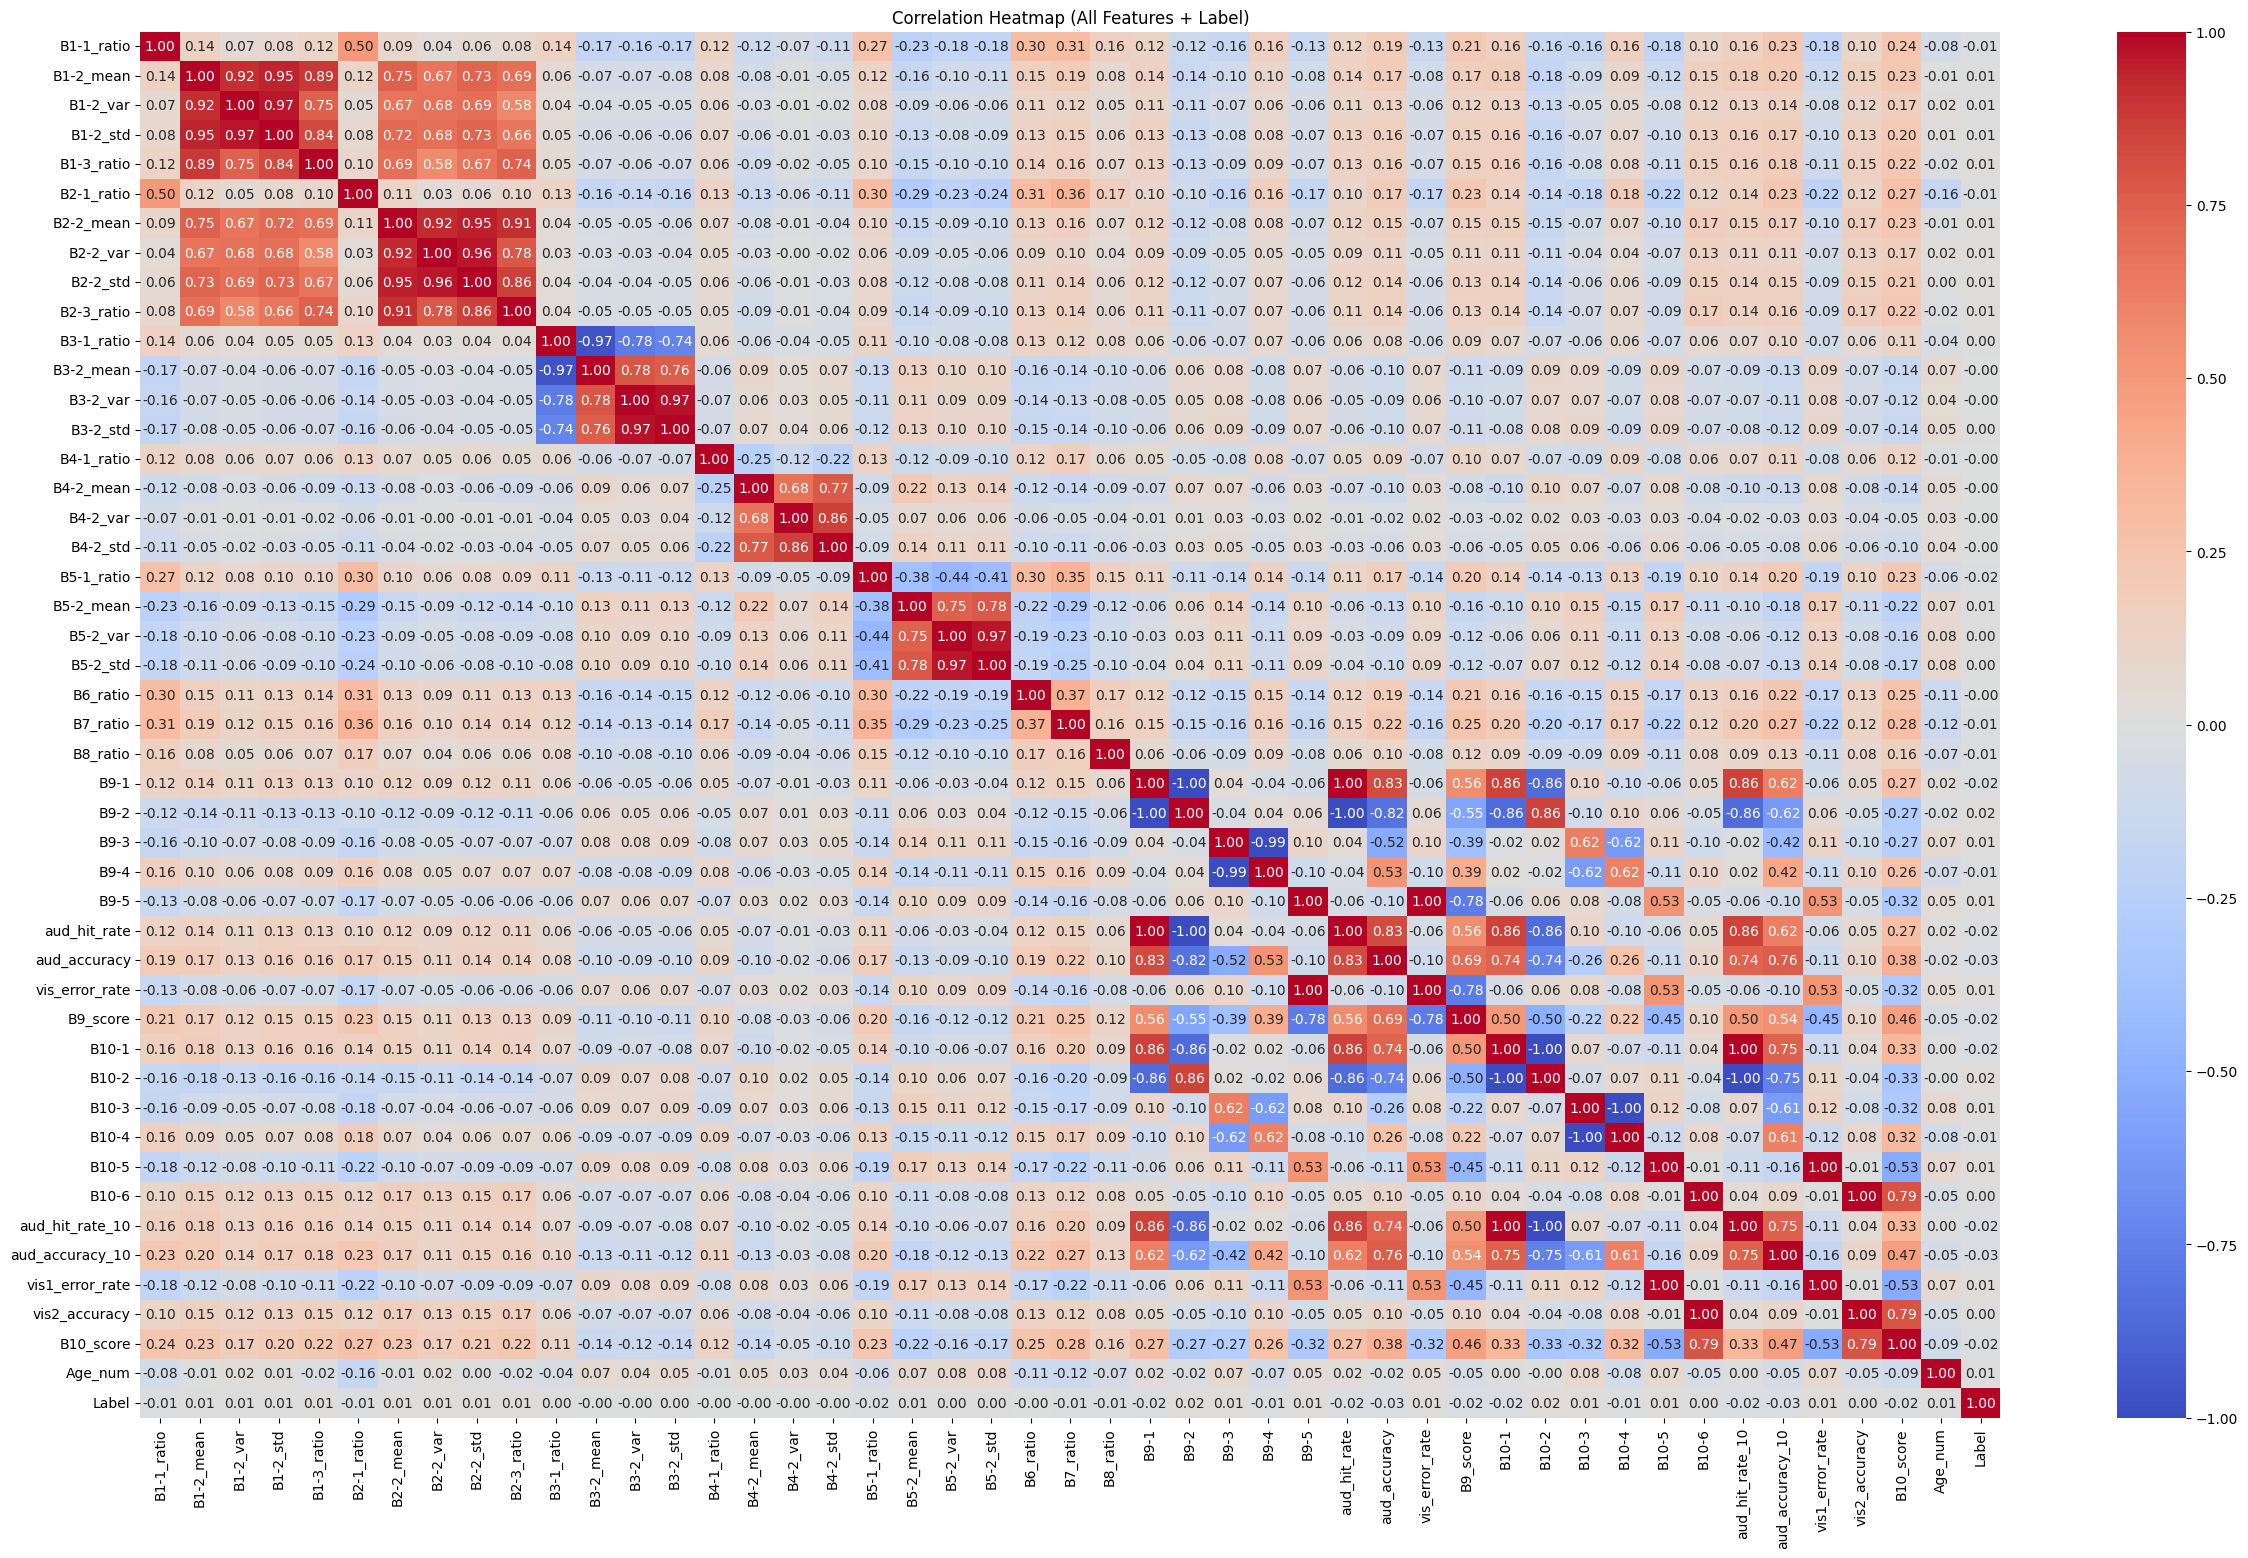

In [20]:
corr_matrix = train_b.corr()

plt.figure(figsize=(30,18))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (All Features + Label)")
plt.show()

### Under Sampling

In [21]:
df_label1 = train_b[train_b['Label'] == 1]
df_label0 = train_b[train_b['Label'] == 0]

n_label1 = len(df_label1)
n_label0 = len(df_label0)

# 0 데이터를 label1 크기에 맞춰 무작위로 샘플링
sample_size = n_label1

np.random.seed(42)  # 재현성

# 테스트로 3개의 히트맵
for i in range(3):
    # Label 0에서 서브샘플링
    df0_sample = df_label0.sample(n=sample_size, replace=False)
    # Label 1과 합치기
    df_bootstrap = pd.concat([df_label1, df0_sample], axis=0).reset_index(drop=True)
    # 상관계수 계산
    corr_matrix = df_bootstrap.corr()

    # 히트맵
    plt.figure(figsize=(30, 18))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title(f"Bootstrap Correlation Heatmap #{i+1}")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

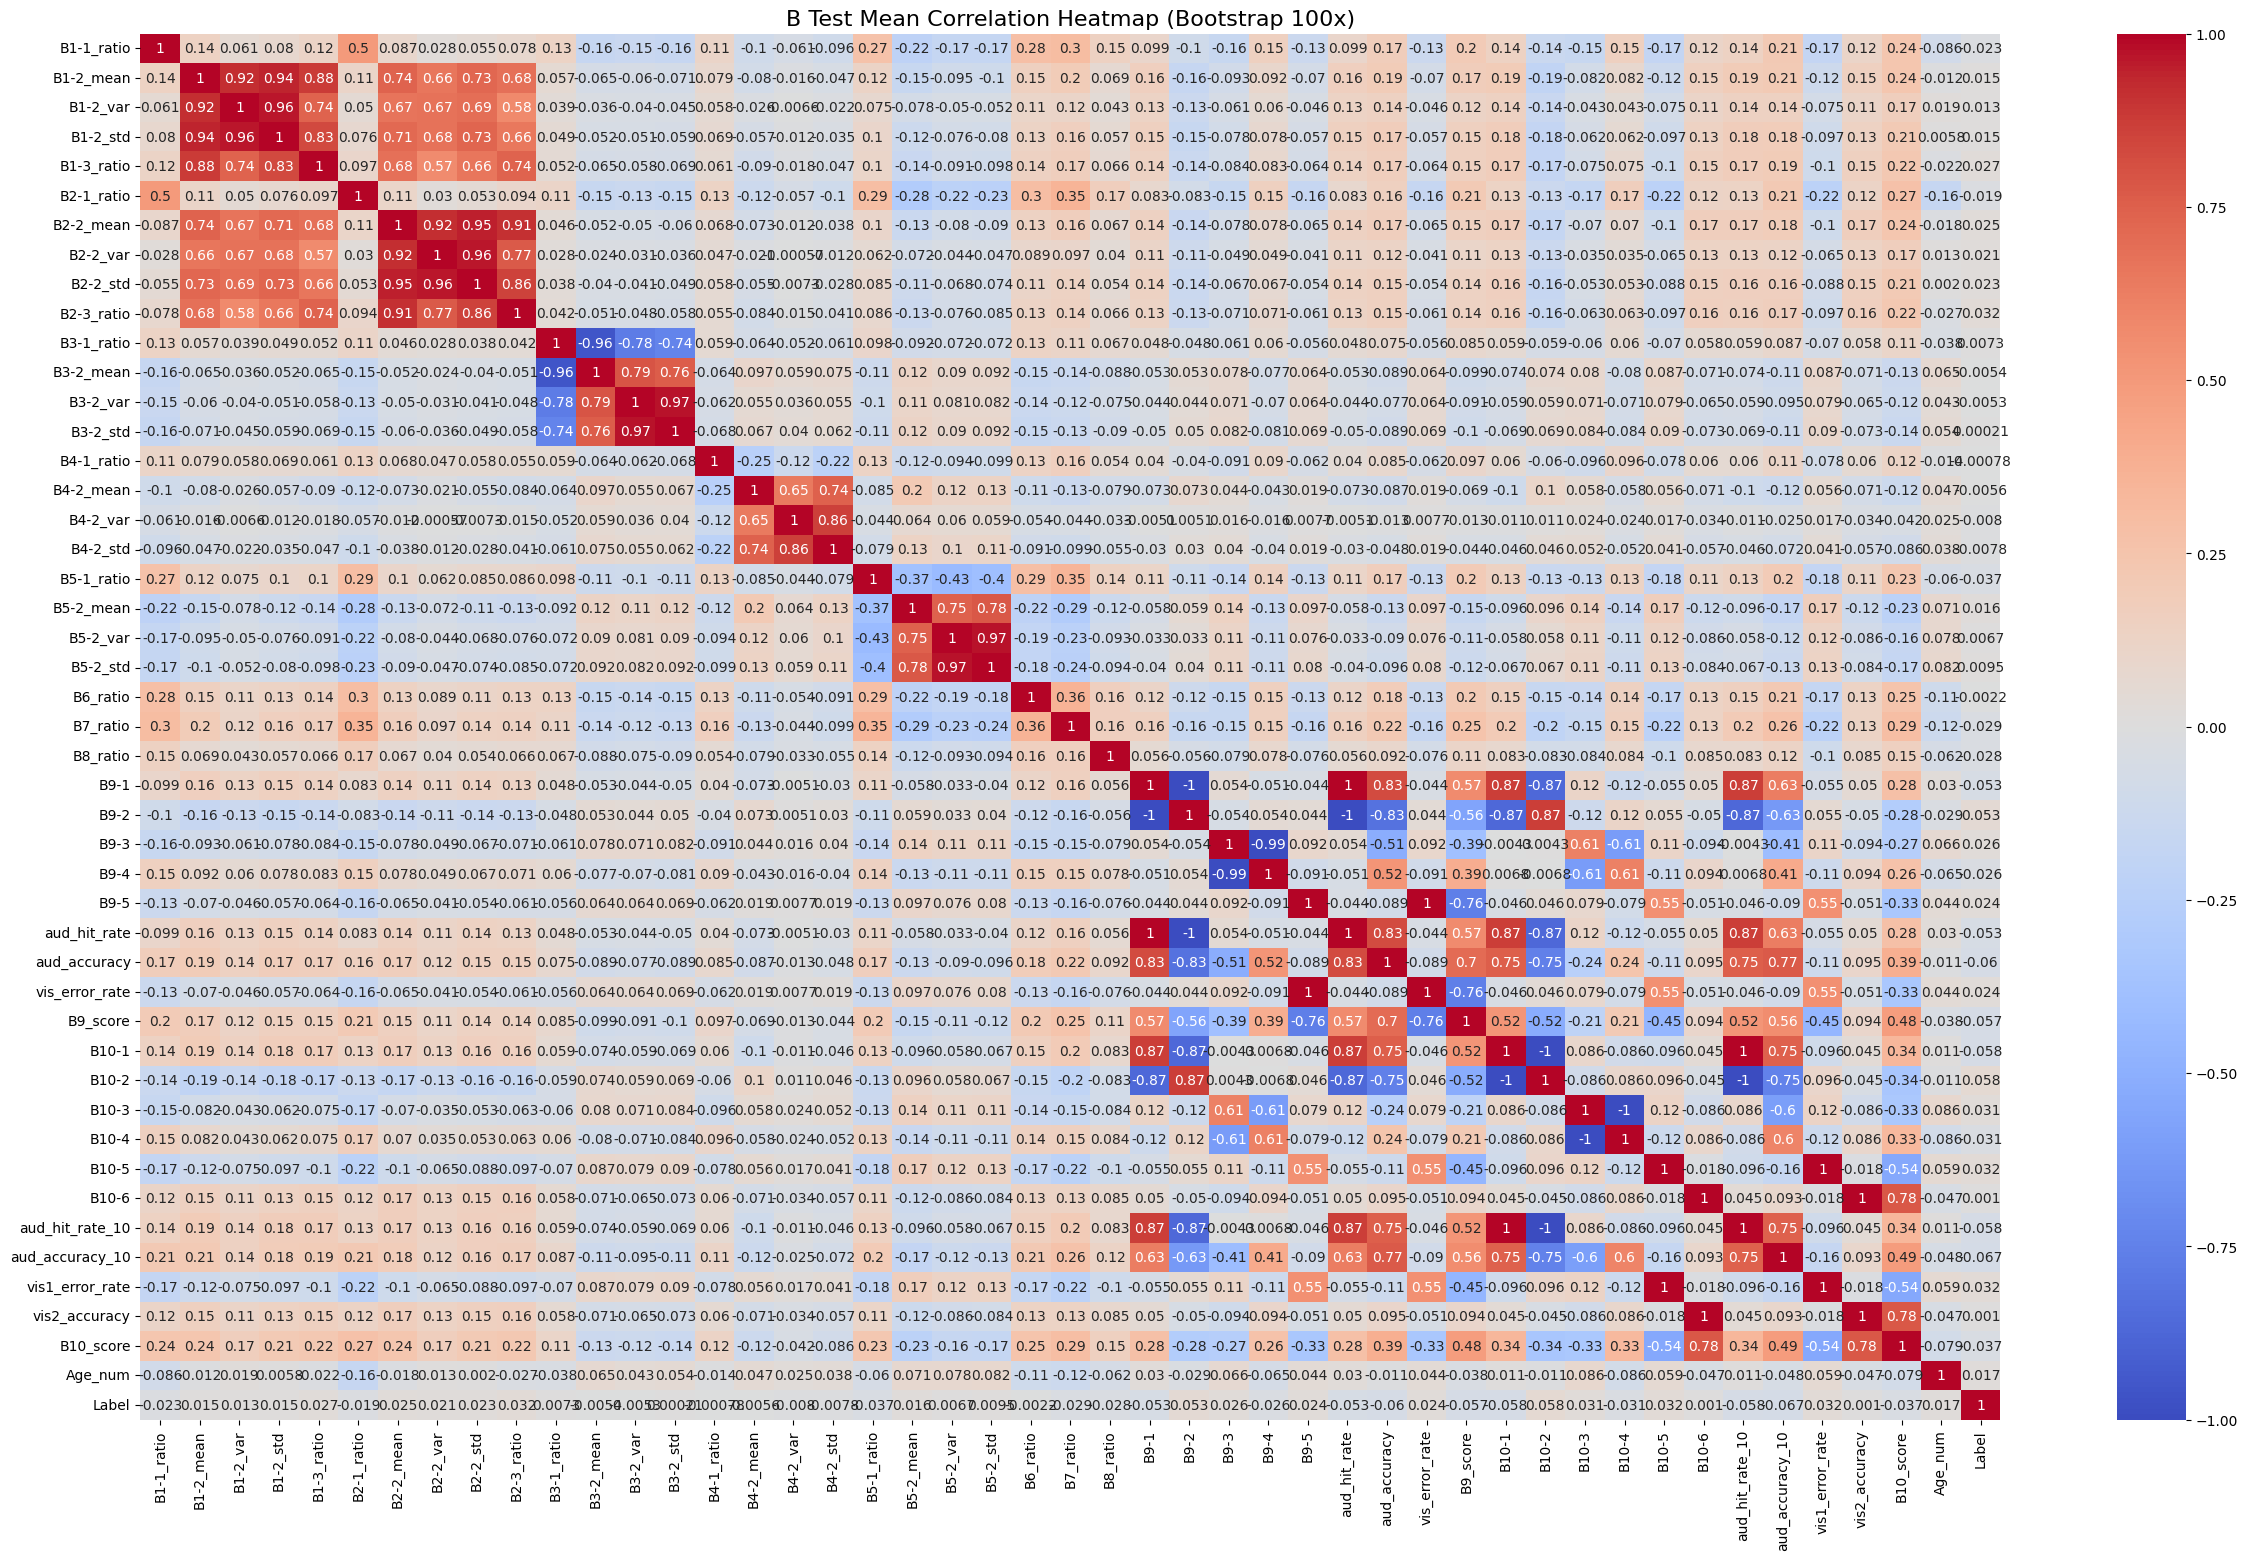

In [23]:
cols = [
    'B1-1_ratio', 'B1-2_mean', 'B1-2_var', 'B1-2_std', 'B1-3_ratio',
    'B2-1_ratio', 'B2-2_mean', 'B2-2_var', 'B2-2_std', 'B2-3_ratio',
    'B3-1_ratio', 'B3-2_mean', 'B3-2_var', 'B3-2_std',
    'B4-1_ratio', 'B4-2_mean', 'B4-2_var', 'B4-2_std',
    'B5-1_ratio', 'B5-2_mean', 'B5-2_var', 'B5-2_std',
    'B6_ratio', 'B7_ratio', 'B8_ratio',
    'B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5',
    'aud_hit_rate', 'aud_accuracy', 'vis_error_rate', 'B9_score',
    'B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5', 'B10-6',
    'aud_hit_rate_10', 'aud_accuracy_10', 'vis1_error_rate', 'vis2_accuracy', 'B10_score',
    'Age_num', 'Label'
]

df_label1 = train_b[train_b['Label'] == 1]
df_label0 = train_b[train_b['Label'] == 0]

n_label1 = len(df_label1)
sample_size = n_label1

np.random.seed(42)
n_bootstrap = 100

corr_accum = np.zeros((len(cols), len(cols)))

for i in range(n_bootstrap):
    df0_sample = df_label0.sample(n=sample_size, replace=False)
    df_bootstrap = pd.concat([df_label1, df0_sample], axis=0).reset_index(drop=True)
    corr_matrix = df_bootstrap[cols].corr()
    corr_accum += corr_matrix.values

corr_mean = corr_accum / n_bootstrap
corr_mean_df = pd.DataFrame(corr_mean, index=cols, columns=cols)

plt.figure(figsize=(30, 18))
sns.heatmap(corr_mean_df, cmap='coolwarm', center=0, annot=True)
plt.title(f"B Test Mean Correlation Heatmap (Bootstrap {n_bootstrap}x)", fontsize=16)
plt.show()

Label과 상관계수 상위 변수: ['Label', 'aud_accuracy_10', 'aud_accuracy', 'B10-2', 'B10-1', 'aud_hit_rate_10', 'B9_score', 'aud_hit_rate', 'B9-1', 'B9-2']


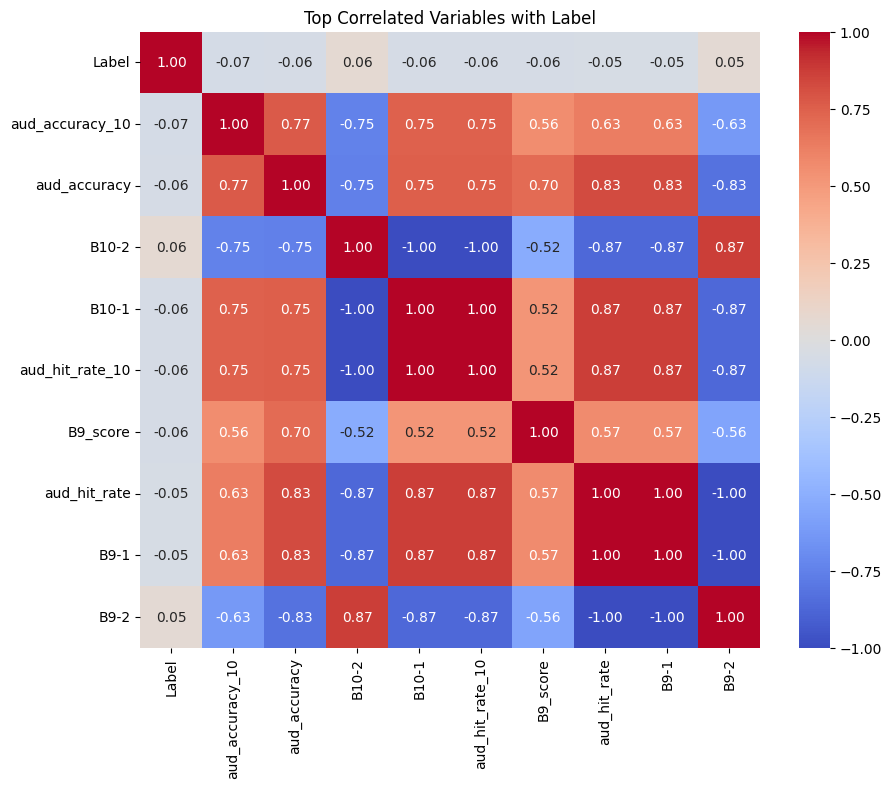

In [24]:
label_corr = corr_mean_df['Label']

# 절댓값 기준 내림차순 정렬
label_corr_sorted = label_corr.abs().sort_values(ascending=False)

# Label과 상관계수 상위 10개 변수 (Label 포함)
top_vars = label_corr_sorted.head(10).index.tolist()

print("Label과 상관계수 상위 변수:", top_vars)

# 상위 변수들만 히트맵 그리기
plt.figure(figsize=(10,8))
sns.heatmap(corr_mean_df.loc[top_vars, top_vars], annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Top Correlated Variables with Label")
plt.show()

### Over Sampling

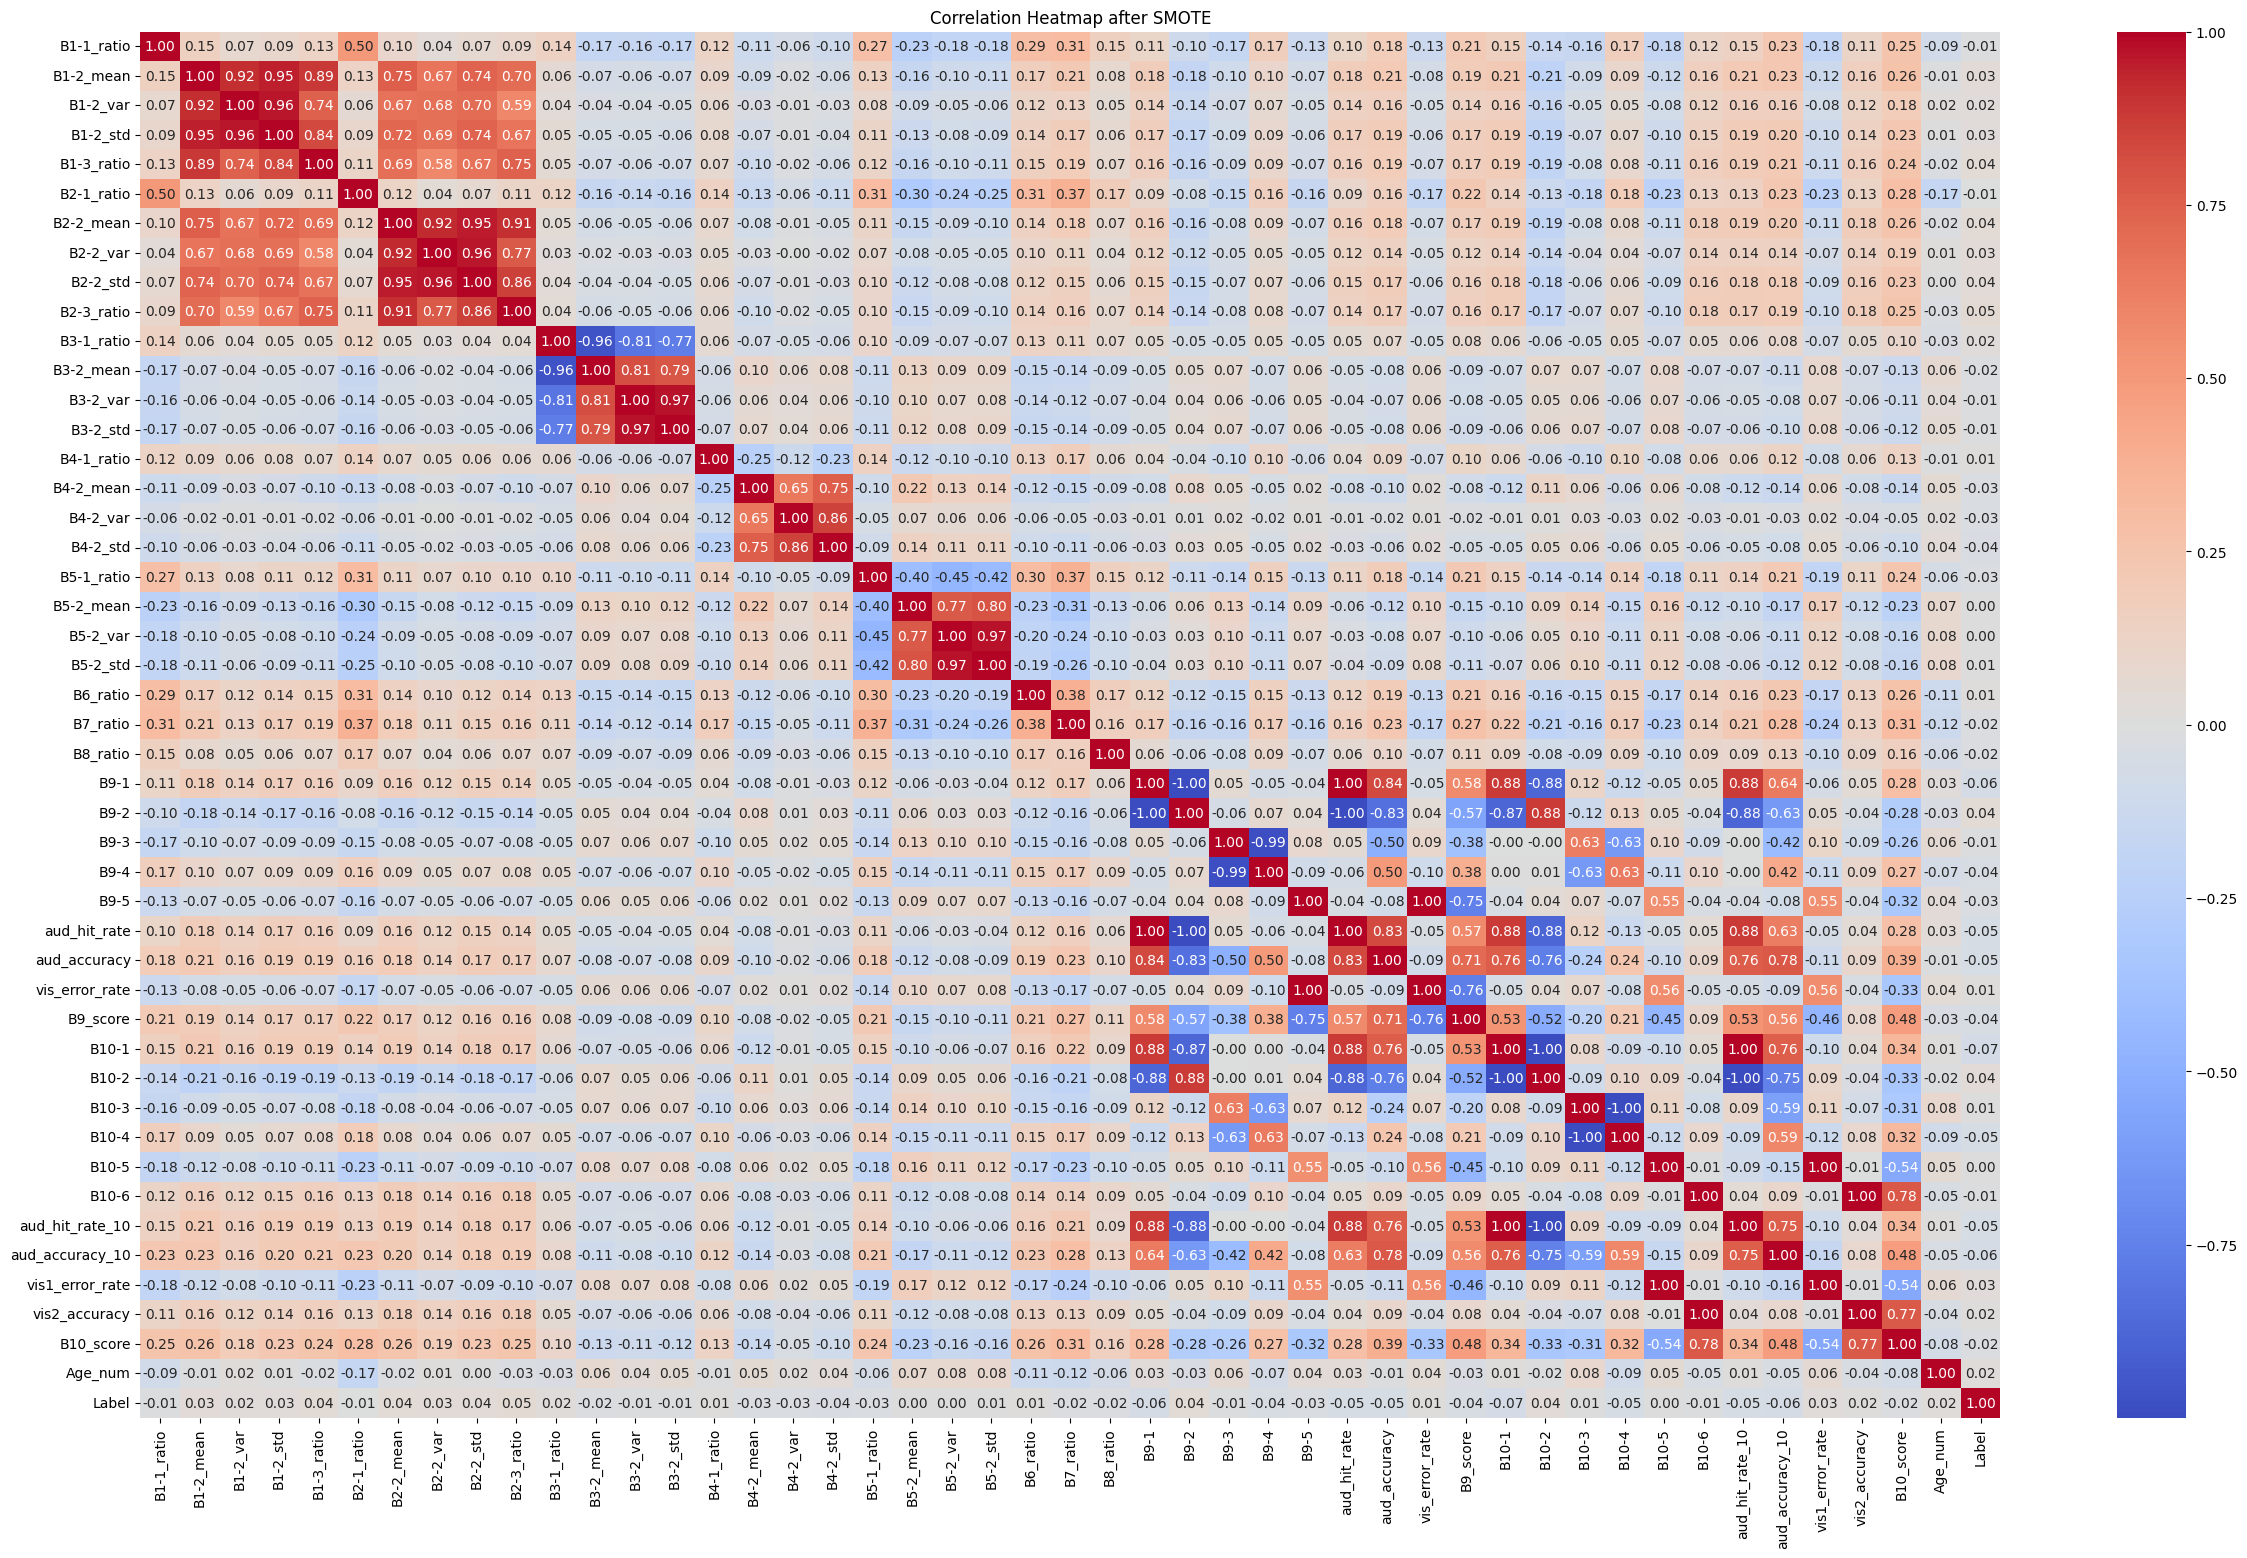

In [25]:
cols = [
    'B1-1_ratio', 'B1-2_mean', 'B1-2_var', 'B1-2_std', 'B1-3_ratio',
    'B2-1_ratio', 'B2-2_mean', 'B2-2_var', 'B2-2_std', 'B2-3_ratio',
    'B3-1_ratio', 'B3-2_mean', 'B3-2_var', 'B3-2_std',
    'B4-1_ratio', 'B4-2_mean', 'B4-2_var', 'B4-2_std',
    'B5-1_ratio', 'B5-2_mean', 'B5-2_var', 'B5-2_std',
    'B6_ratio', 'B7_ratio', 'B8_ratio',
    'B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5',
    'aud_hit_rate', 'aud_accuracy', 'vis_error_rate', 'B9_score',
    'B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5', 'B10-6',
    'aud_hit_rate_10', 'aud_accuracy_10', 'vis1_error_rate', 'vis2_accuracy', 'B10_score',
    'Age_num', 'Label'
]

tmp = train_b.copy()

x = tmp.drop('Label', axis=1)
y = tmp['Label']

smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

df_res = x_res.copy()
df_res['Label'] = y_res

corr_res = df_res.corr()

plt.figure(figsize=(30, 18))
sns.heatmap(corr_res, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap after SMOTE")
plt.show()

Label과 상관계수 상위 변수: ['Label', 'B10-1', 'aud_accuracy_10', 'B9-1', 'aud_hit_rate_10', 'B2-3_ratio', 'aud_accuracy', 'aud_hit_rate', 'B10-4', 'B1-3_ratio']


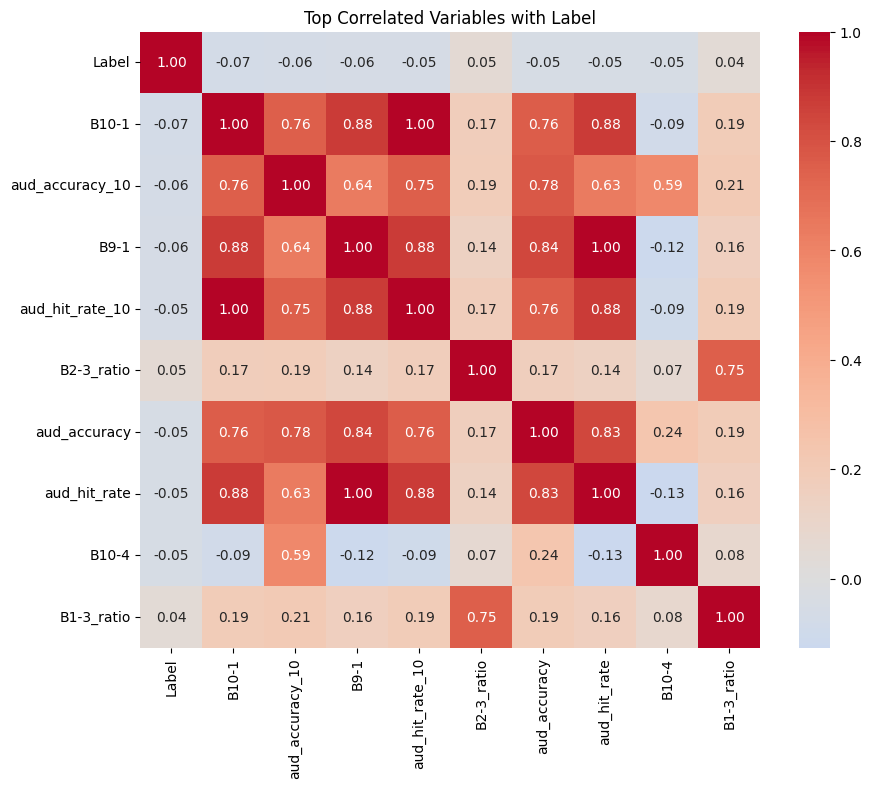

In [26]:
label_corr = corr_res['Label']

# 절댓값 기준 내림차순 정렬
label_corr_sorted = label_corr.abs().sort_values(ascending=False)

# Label과 상관계수 상위 10개 변수 (Label 포함)
top_vars = label_corr_sorted.head(10).index.tolist()

print("Label과 상관계수 상위 변수:", top_vars)

# 상위 변수들만 히트맵 그리기
plt.figure(figsize=(10,8))
sns.heatmap(corr_res.loc[top_vars, top_vars], annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Top Correlated Variables with Label")
plt.show()

### LightGBM

In [27]:
cols = [
    'B1-1_ratio', 'B1-2_mean', 'B1-2_var', 'B1-2_std', 'B1-3_ratio',
    'B2-1_ratio', 'B2-2_mean', 'B2-2_var', 'B2-2_std', 'B2-3_ratio',
    'B3-1_ratio', 'B3-2_mean', 'B3-2_var', 'B3-2_std',
    'B4-1_ratio', 'B4-2_mean', 'B4-2_var', 'B4-2_std',
    'B5-1_ratio', 'B5-2_mean', 'B5-2_var', 'B5-2_std',
    'B6_ratio', 'B7_ratio', 'B8_ratio',
    'B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5',
    'aud_hit_rate', 'aud_accuracy', 'vis_error_rate', 'B9_score',
    'B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5', 'B10-6',
    'aud_hit_rate_10', 'aud_accuracy_10', 'vis1_error_rate', 'vis2_accuracy', 'B10_score',
    'Age_num'
]

x = train_b[cols]
y = train_b['Label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',  # 불균형 고려
    random_state=42
)

model.fit(x_train, y_train)

importances = pd.DataFrame({
    'feature': cols,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances.head(20))  # 상위 20개 확인

[LightGBM] [Info] Number of positive: 10070, number of negative: 227940
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5045
[LightGBM] [Info] Number of data points in the train set: 238010, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
            feature  importance
11        B3-2_mean        1091
19        B5-2_mean        1046
15        B4-2_mean        1021
12         B3-2_var        1016
20         B5-2_var         920
16         B4-2_var         913
44        B10_score         818
14       B4-1_ratio         583
6         B2-2_mean         582
1         B1-2_mean         573
2          B1-2_var         558
7          B2-2_var         540
33         B9_score       

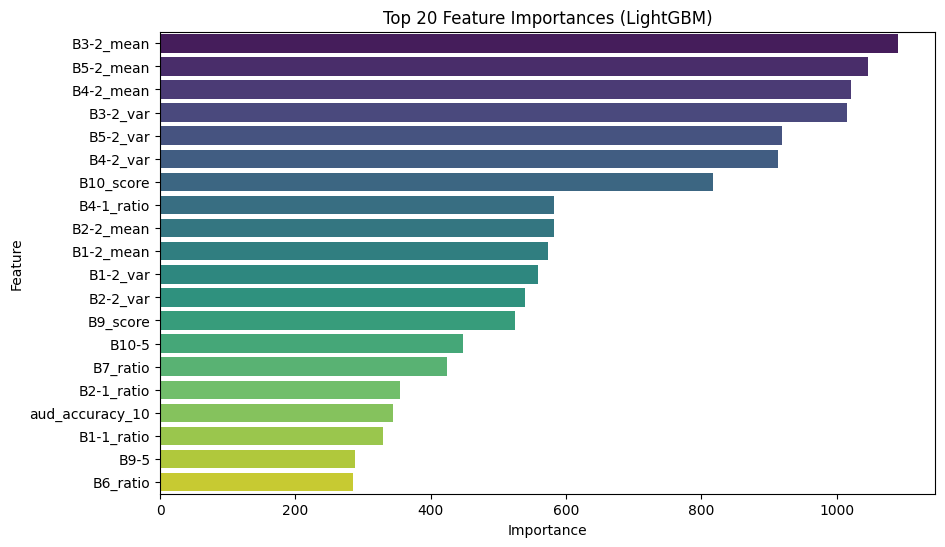

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### SHAP

Computing SHAP values: 100%|██████████| 239/239 [20:24<00:00,  5.12s/it]


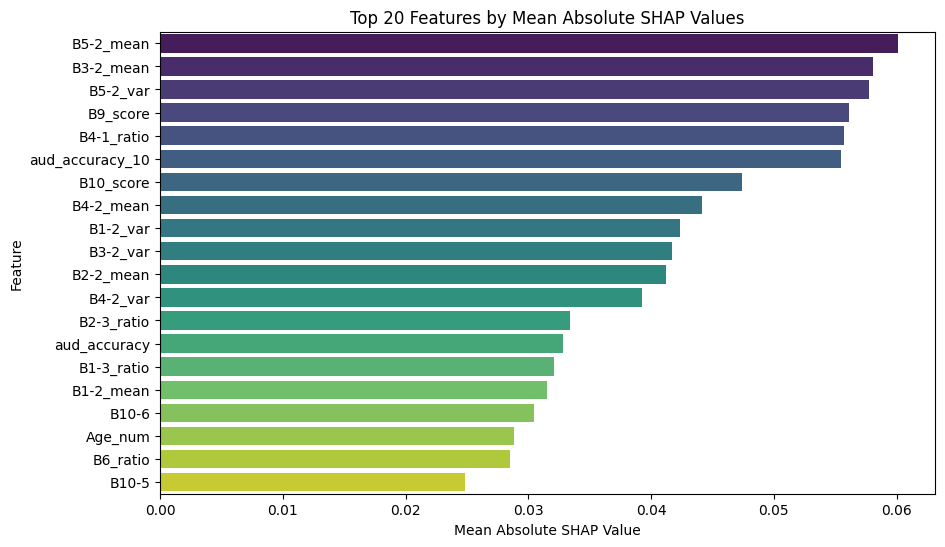

In [29]:
explainer = shap.TreeExplainer(model)

batch_size = 1000
n_samples = len(x_train)
shap_values_list = []

for i in tqdm(range(0, n_samples, batch_size), desc="Computing SHAP values"):
    x_batch = x_train.iloc[i:i+batch_size]
    shap_values_batch = explainer.shap_values(x_batch)[1]  # 이진분류이므로 [1]
    shap_values_list.append(shap_values_batch)

# 전체 shap_values 합치기
shap_values_class1 = np.vstack(shap_values_list)

# 평균 절댓값 계산
shap_abs_mean = pd.DataFrame({
    'feature': x_train.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

# 시각화
plt.figure(figsize=(10,6))
sns.barplot(data=shap_abs_mean.head(20), x='mean_abs_shap', y='feature', palette='viridis')
plt.title('Top 20 Features by Mean Absolute SHAP Values')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.show()
